In [34]:
import pandas as pd
import lasio
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [17]:
d = Path("/home/py/Documents/alberta_maps/DIG_2021_0027")

In [18]:
idx = pd.read_csv(d / "DIG 2021-0027.txt", sep="\t", encoding="utf-8")
idx["Long_NAD83"] = -idx["Long_NAD83"]

In [19]:
my_ids = [370217.0, 370209.0, 370221.0, 370213.0, 370218.0, 496371.0, 496372.0, 1021710.0, 404368.0]

In [20]:
hits = idx[idx["GIC_W_ID"].isin(my_ids)]

In [21]:
hits

,LAS_FI_Nam,GIC_W_ID,Long_NAD83,Lat_NAD83,UTM83_Z,E_UTM83,N_UTM83,E_10TM83,N_10TM83,El_DEM15_m,DLS_Loc,Curve_Type,Shortname,Publisher
13645,370217-a,370217.0,-115.153972,50.95006,11.0,629668,5645894,489190,5642023,1606,141102309W5,Depth in Feet; Spontaneous Potential,DEPT; SP; RES,Alberta Geological Survey


In [25]:
LAS_DIR = d /"LAS_Files"
for stem in hits['LAS_FI_Nam']:
    found = list(LAS_DIR.glob(f"{stem}.*"))
    print(stem, "->", found if found else "NOT FOUND")

370217-a -> [PosixPath('/home/py/Documents/alberta_maps/DIG_2021_0027/LAS_Files/370217-a.las')]


In [30]:
las = lasio.read(LAS_DIR / "370217-a.las")

In [32]:
print(las.curves)

Mnemonic  Unit  Value         Description            
--------  ----  -----         -----------            
DEPT      FT                  Depth in Feet          
SP        MV    01 010 01 01  Spontaneous Potential  
RES       OHMM                                       


In [33]:
df = las.df()
df.index = df.index * 0.3048
df.index.name = "DEPT_m"
df

,SP,RES
DEPT_m,,
3.0480,-481.012658,789.607098
3.2004,-481.012658,789.607098
3.3528,-481.012658,789.607098
3.5052,-481.163291,759.188847
3.6576,-481.358228,590.874525
...,...,...
11.5824,440.330305,1021.596972
11.7348,446.408779,1061.130804
11.8872,466.164731,1238.477870


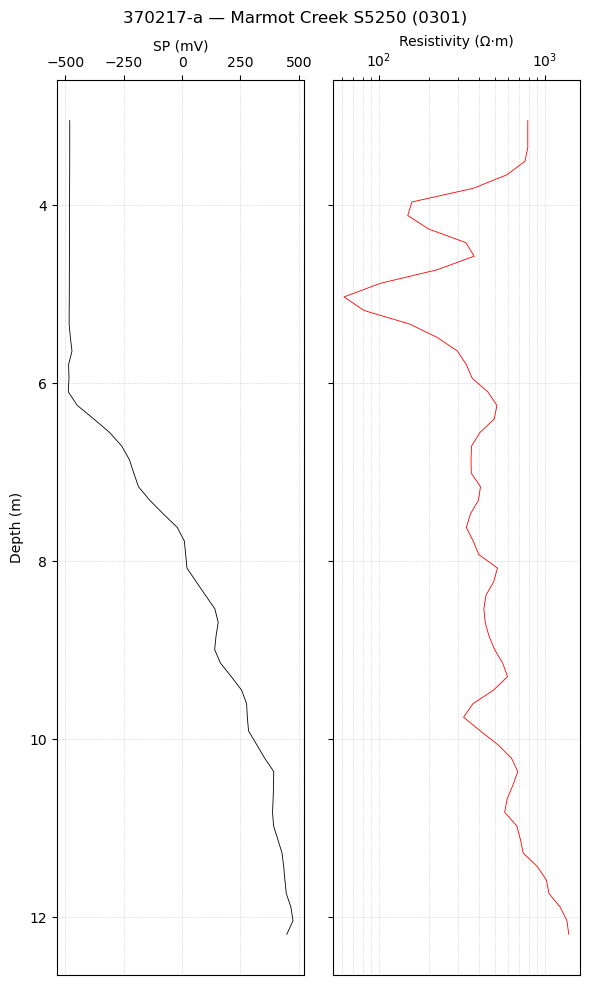

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 10), sharey=True)

ax[0].plot(df["SP"], df.index, color="black", lw=0.6)
ax[0].set_xlabel("SP (mV)")
ax[0].set_ylabel("Depth (m)")

ax[1].plot(df["RES"], df.index, color="red", lw=0.6)
ax[1].set_xscale("log")                     # standard for resistivity
ax[1].set_xlabel("Resistivity (Ω·m)")

for a in ax:
    a.grid(True, which="both", ls=":", lw=0.4)
    a.xaxis.set_label_position("top")
    a.xaxis.tick_top()   # header labels on top

ax[0].invert_yaxis()                         # depth increases downward
fig.suptitle("370217-a — Marmot Creek S5250 (0301)")
plt.tight_layout()

In [36]:
print(df.describe())                         # ranges, spot bad values
thr = df["RES"].quantile(0.75)               # crude upper-quartile cut
candidates = df[df["RES"] > thr]
print(candidates.index.min(), "–", candidates.index.max(), "m")

               SP          RES
count   61.000000    61.000000
mean   -64.620151   510.784212
std    372.475023   285.444240
min   -487.354091    61.760736
25%   -481.163291   359.501373
50%    -20.690462   442.124765
75%    284.666239   629.171216
max    475.102742  1393.889720
3.048 – 12.192 m
